# Clustering Results

This notebook loads `scores.csv` and visualizes the relationship between the initial number of clusters, the clustering scores, and the final number of clusters.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


In [2]:
scores_path = Path("scores.csv")
scores_df = pd.read_csv(scores_path)

numeric_columns = [
    "No. Init_clusters",
    "Init_semantic_score",
    "Init_Silhouette_score",
    "No. Final_clusters",
    "Final_semantic_score",
    "Final_Silhouette_score",
]
scores_df[numeric_columns] = scores_df[numeric_columns].apply(pd.to_numeric)
scores_df.head()


,No. Init_clusters,Init_semantic_score,Init_Silhouette_score,No. Final_clusters,Final_semantic_score,Final_Silhouette_score
0,2,0.48,0.66,2,0.48,0.66
1,3,0.26,0.47,3,0.26,0.47
2,4,0.31,0.40,3,0.47,0.42
3,5,0.27,0.35,3,0.47,0.42
4,6,0.24,0.36,3,0.47,0.42


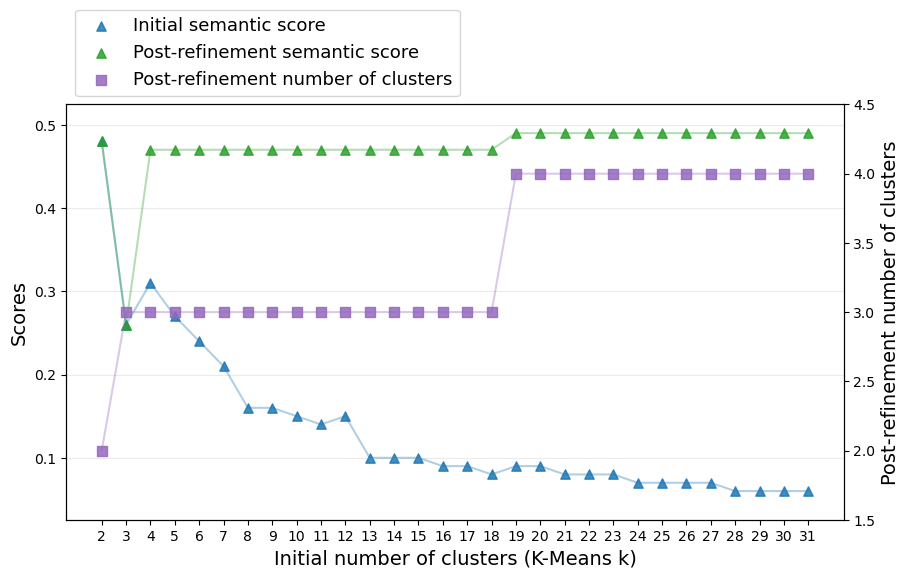

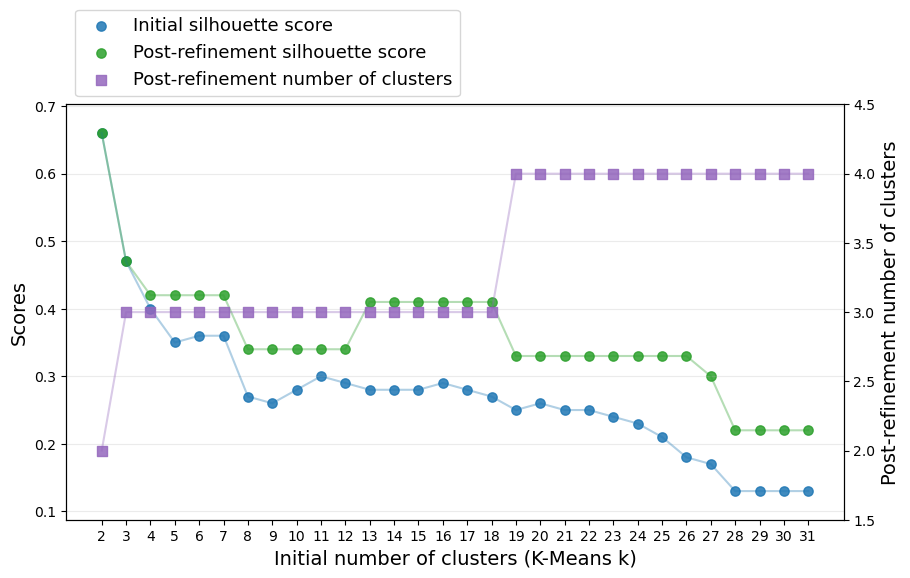

In [3]:
output_dir = Path(".")
TITLE_FONT_SIZE = 18
LABEL_FONT_SIZE = 14
TICK_FONT_SIZE = 10
LEGEND_FONT_SIZE = 13
x = scores_df["No. Init_clusters"]
final_clusters_min = scores_df["No. Final_clusters"].min()
final_clusters_max = scores_df["No. Final_clusters"].max()

def plot_score_group(score_columns, title, pdf_name):
    fig, ax_left = plt.subplots(figsize=(10, 6))
    ax_right = ax_left.twinx()

    for column, label, color, marker in score_columns:
        ax_left.scatter(x, scores_df[column], label=label, color=color, marker=marker, s=45, alpha=0.85)
        ax_left.plot(x, scores_df[column], color=color, alpha=0.35)

    ax_right.scatter(
        x,
        scores_df["No. Final_clusters"],
        label="Post-refinement number of clusters",
        color="tab:purple",
        marker="s",
        s=45,
        alpha=0.85,
    )
    ax_right.plot(x, scores_df["No. Final_clusters"], color="tab:purple", alpha=0.35)

    ax_left.set_xlabel("Initial number of clusters (K-Means k)", fontsize=LABEL_FONT_SIZE)
    ax_left.set_ylabel("Scores", fontsize=LABEL_FONT_SIZE)
    ax_right.set_ylabel("Post-refinement number of clusters", fontsize=LABEL_FONT_SIZE)
    ax_left.set_title(title, fontsize=TITLE_FONT_SIZE)

    score_min = scores_df[[column for column, _, _, _ in score_columns]].min().min()
    score_max = scores_df[[column for column, _, _, _ in score_columns]].max().max()
    score_padding = max(0.02, (score_max - score_min) * 0.08)
    ax_left.set_ylim(score_min - score_padding, score_max + score_padding)
    ax_right.set_ylim(final_clusters_min - 0.5, final_clusters_max + 0.5)

    ax_left.set_xticks(x)
    ax_left.tick_params(axis="both", labelsize=TICK_FONT_SIZE)
    ax_right.tick_params(axis="y", labelsize=TICK_FONT_SIZE)
    ax_left.grid(True, axis="y", alpha=0.25)

    left_handles, left_labels = ax_left.get_legend_handles_labels()
    right_handles, right_labels = ax_right.get_legend_handles_labels()
    ax_left.legend(
        left_handles + right_handles,
        left_labels + right_labels,
        loc="upper left",
        bbox_to_anchor=(0, 1.25),
        fontsize=LEGEND_FONT_SIZE,
    )
    plt.tight_layout(rect=(0.08, 0.0, 1.0, 1.0))
    fig.savefig(output_dir / pdf_name, format="pdf", bbox_inches="tight")
    plt.show()

plot_score_group(
    [
        ("Init_semantic_score", "Initial semantic score", "tab:blue", "^"),
        ("Final_semantic_score", "Post-refinement semantic score", "tab:green", "^"),
    ],
    "",
    "semantic_scores_vs_clusters.pdf",
)

plot_score_group(
    [
        ("Init_Silhouette_score", "Initial silhouette score", "tab:blue", "o"),
        ("Final_Silhouette_score", "Post-refinement silhouette score", "tab:green", "o"),
    ],
    "",
    "silhouette_scores_vs_clusters.pdf",
)
